In [1]:
!pip install -q librosa soundfile audiomentations pandas matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 13.5 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift
from IPython.display import Audio, display

In [11]:
# Change only if your username folder uses capital letters
MY_NAME = 'wagner'

# Base path - adjust if you uploaded to a different top-level folder
BASE_AUDIO_DIR = "/content/content/recordings/originals"
MY_AUDIO_DIR = os.path.join(BASE_AUDIO_DIR, MY_NAME)

print("Looking for your audio files in:", MY_AUDIO_DIR)

# Check if folder exists and list files
if os.path.exists(MY_AUDIO_DIR):
    audio_files = [f for f in os.listdir(MY_AUDIO_DIR)
                   if f.lower().endswith(('.wav', '.mp3', '.m4a'))]
    audio_files.sort()
    print(f"Found {len(audio_files)} audio files:")
    for f in audio_files:
        print("   ", f)
else:
    print("Folder not found. Please upload your files to:", MY_AUDIO_DIR)

Looking for your audio files in: /content/content/recordings/originals/wagner
Found 4 audio files:
    Acess denied.wav
    No, cancel.wav
    Yes, approve.wav
    comfirm_transaction.wav



=== Acess denied.wav ===
Duration: 1.15 seconds | Sample rate: 24000 Hz


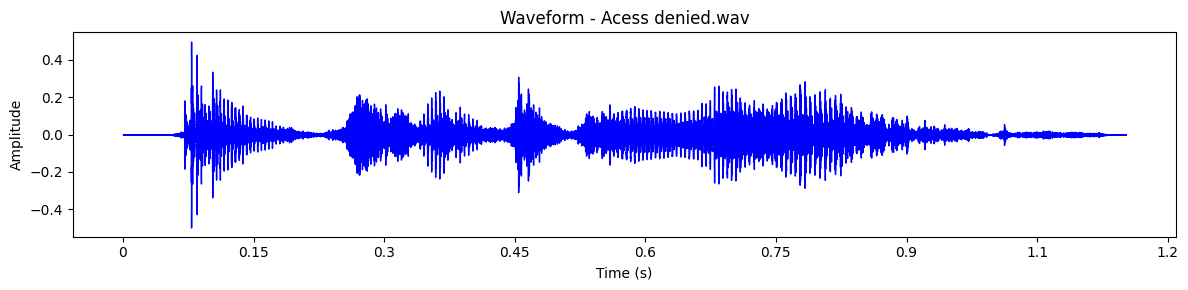

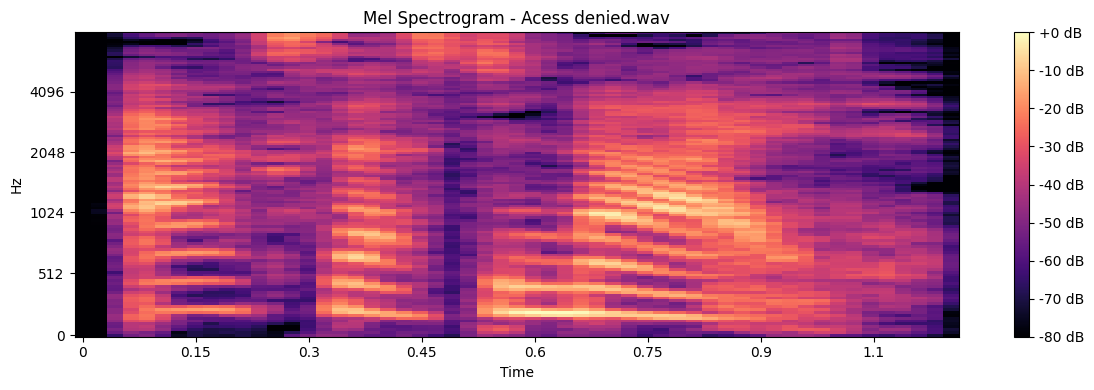


=== No, cancel.wav ===
Duration: 1.39 seconds | Sample rate: 24000 Hz


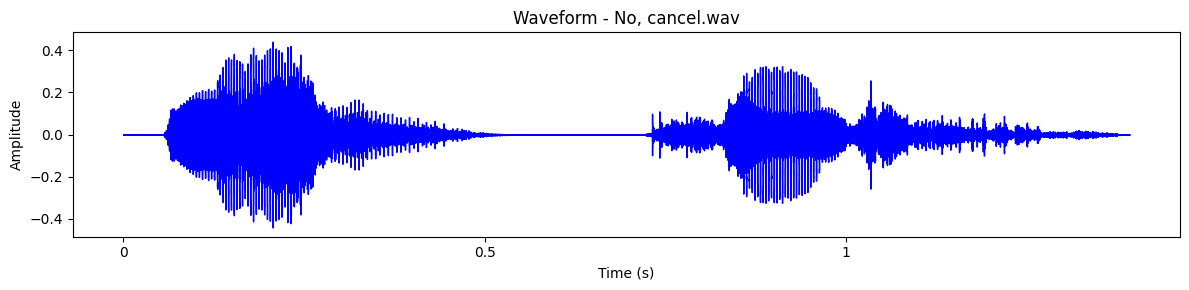

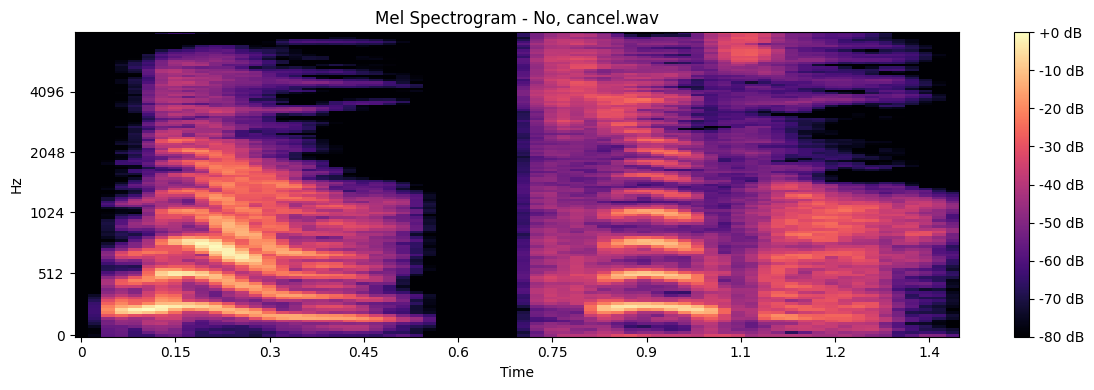


=== Yes, approve.wav ===
Duration: 1.22 seconds | Sample rate: 24000 Hz


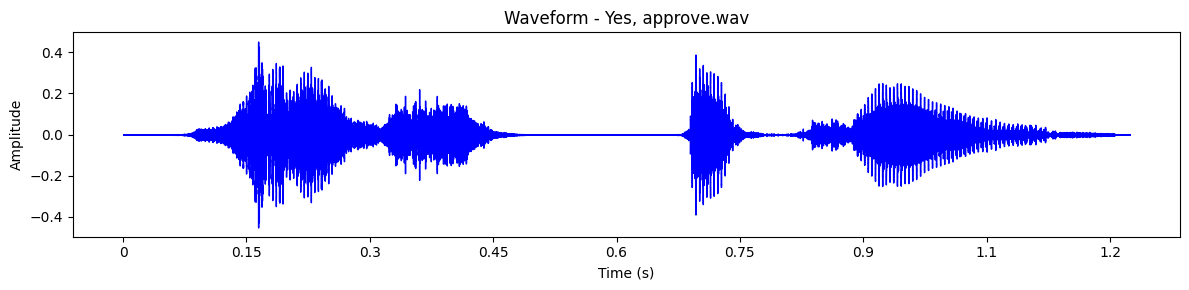

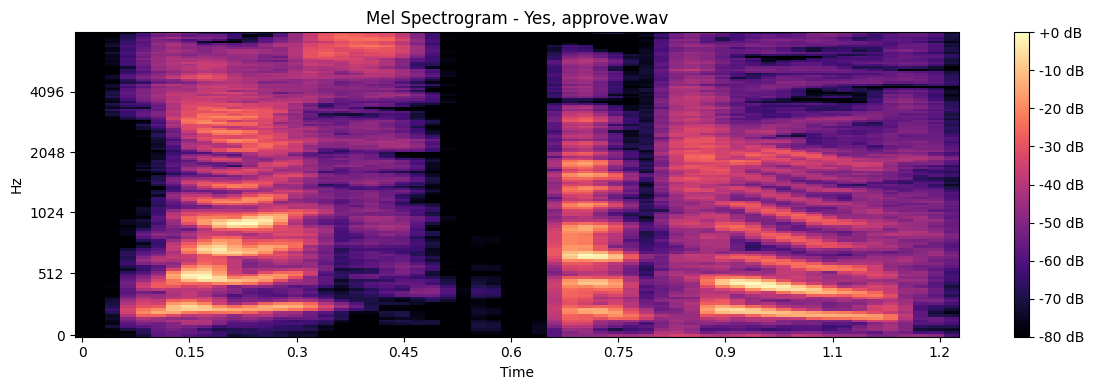


=== comfirm_transaction.wav ===
Duration: 1.34 seconds | Sample rate: 24000 Hz


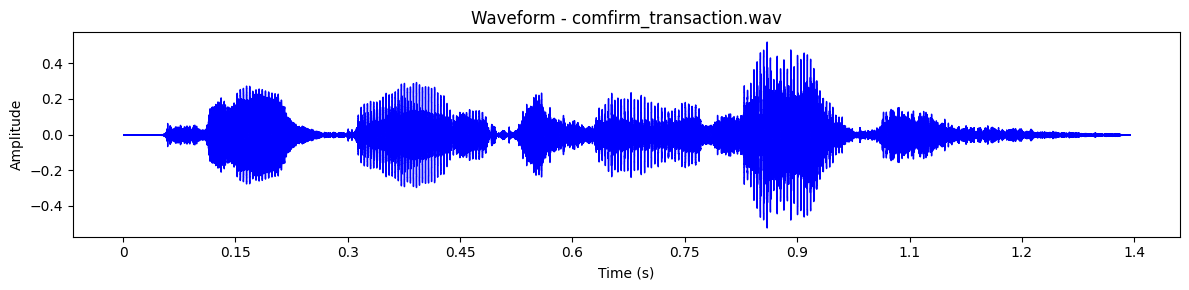

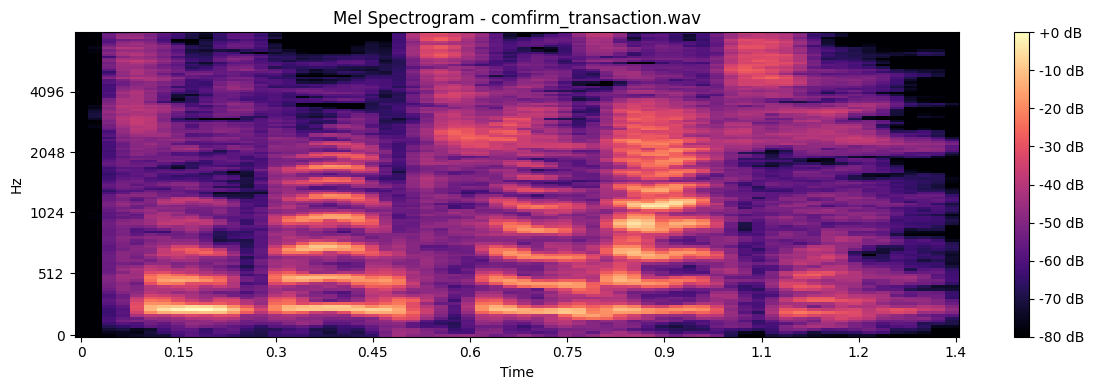

In [12]:
for filename in audio_files:
    filepath = os.path.join(MY_AUDIO_DIR, filename)
    try:
        y, sr = librosa.load(filepath, sr=None)

        print(f"\n=== {filename} ===")
        print(f"Duration: {len(y)/sr:.2f} seconds | Sample rate: {sr} Hz")

        # Play audio
        display(Audio(y, rate=sr))

        # Waveform
        plt.figure(figsize=(12, 3))
        librosa.display.waveshow(y, sr=sr, color='blue')
        plt.title(f'Waveform - {filename}')
        plt.xlabel('Time (s)')
        plt.ylabel('Amplitude')
        plt.tight_layout()
        plt.show()

        # Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
        S_dB = librosa.power_to_db(S, ref=np.max)

        plt.figure(figsize=(12, 4))
        librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
        plt.colorbar(format='%+2.0f dB')
        plt.title(f'Mel Spectrogram - {filename}')
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error loading {filename}: {e}")

In [14]:
# Augmentation
augment_pipeline = Compose([
    AddGaussianNoise(min_amplitude=0.005, max_amplitude=0.015, p=0.6),
    TimeStretch(min_rate=0.85, max_rate=1.20, p=0.6),
    PitchShift(min_semitones=-3.5, max_semitones=3.5, p=0.6),

])

In [15]:
def extract_audio_features(y, sr):
    # MFCCs (13 is standard)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = np.mean(mfccs, axis=1)

    # Other common features (means)
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    spec_rolloff   = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    zcr            = np.mean(librosa.feature.zero_crossing_rate(y))
    rms            = np.mean(librosa.feature.rms(y=y))

    features = {
        'mfcc_' + str(i): mfcc_means[i] for i in range(13)
    }
    features.update({
        'spectral_centroid_mean': spec_centroid,
        'spectral_rolloff_mean': spec_rolloff,
        'zero_crossing_rate_mean': zcr,
        'rms_mean': rms,
    })

    return features

In [16]:
data_rows = []

for filename in audio_files:
    filepath = os.path.join(MY_AUDIO_DIR, filename)
    y, sr = librosa.load(filepath, sr=None)

    # Guess phrase from filename (you can edit manually later if needed)
    phrase = 'yes_approve' if any(word in filename.lower() for word in ['yes', 'approve', 'arrove']) else 'confirm_transaction'

    # Original
    feats = extract_audio_features(y, sr)
    row = {
        'filename': filename,
        'user_id': MY_NAME,
        'phrase': phrase,
        'is_augmented': False,
        'aug_type': 'original',
        **feats
    }
    data_rows.append(row)

    # Create 2 augmentations per original
    for i in range(2):
        y_aug = augment_pipeline(samples=y, sample_rate=sr)
        feats_aug = extract_audio_features(y_aug, sr)
        row_aug = {
            'filename': f"{filename}_aug_{i+1}",
            'user_id': MY_NAME,
            'phrase': phrase,
            'is_augmented': True,
            'aug_type': f'aug_{i+1}',
            **feats_aug
        }
        data_rows.append(row_aug)

# Create DataFrame
df_features = pd.DataFrame(data_rows)

print("Shape of final features DataFrame:", df_features.shape)
display(df_features.head(8))   # show some rows

Shape of final features DataFrame: (12, 22)


,filename,user_id,phrase,is_augmented,aug_type,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,...,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,spectral_centroid_mean,spectral_rolloff_mean,zero_crossing_rate_mean,rms_mean
0,Acess denied.wav,wagner,confirm_transaction,False,original,-286.880951,63.551456,-33.746113,4.142834,-20.346342,...,17.876719,-17.294302,-0.268573,-22.121857,4.255124,-12.004223,3477.173271,5701.278409,0.219567,0.040719
1,Acess denied.wav_aug_1,wagner,confirm_transaction,True,aug_1,-207.699112,45.416576,-23.998707,17.099836,-26.694016,...,25.873981,-19.682819,19.743290,-22.770906,12.299047,-21.102556,4257.943464,7748.650568,0.285085,0.040538
2,Acess denied.wav_aug_2,wagner,confirm_transaction,True,aug_2,-338.617706,81.641861,-40.111492,18.583496,-28.978113,...,20.340561,-12.788223,8.732764,-18.229479,-2.281934,-12.098173,2914.173461,4837.286932,0.192480,0.034586
3,"No, cancel.wav",wagner,confirm_transaction,False,original,-358.172028,93.388382,14.745001,-3.881125,-38.129463,...,-0.976781,-4.763524,-4.434247,-13.590528,1.395795,-3.317817,2685.750308,4570.845170,0.179214,0.046255
4,"No, cancel.wav_aug_1",wagner,confirm_transaction,True,aug_1,-259.078186,30.524698,8.315042,-4.386813,-10.830482,...,-0.509614,-2.614300,-3.033905,-5.220019,-3.261902,-1.907469,4032.153904,7704.545455,0.233680,0.041722
5,"No, cancel.wav_aug_2",wagner,confirm_transaction,True,aug_2,-212.968140,30.015945,6.833109,-8.991552,-11.659203,...,-2.897734,-3.876400,-5.012975,-5.142779,-2.978896,-3.226722,4578.405752,8690.518466,0.276167,0.047986
6,"Yes, approve.wav",wagner,yes_approve,False,original,-359.805664,46.656052,-11.923418,5.035281,-15.197784,...,1.656816,-10.506684,-2.037009,-15.209644,-1.159086,-17.266972,3605.870515,6302.060884,0.217765,0.042832
7,"Yes, approve.wav_aug_1",wagner,yes_approve,True,aug_1,-367.029266,44.606487,-10.472999,4.797292,-14.653441,...,0.054879,-10.740759,-2.740374,-14.179955,-1.067863,-18.388359,3514.879355,6175.983297,0.221688,0.045041


In [17]:
#saving the csv file
output_csv_path = os.path.join(BASE_AUDIO_DIR, MY_NAME, f"audio_features_{MY_NAME}.csv")

df_features.to_csv(output_csv_path, index=False)
print("Saved features to:", output_csv_path)

# Optional: also save a copy to the root for easy download
df_features.to_csv("/content/audio_features_wagner.csv", index=False)
print("Also saved a copy to: /content/audio_features_wagner.csv")

Saved features to: /content/content/recordings/originals/wagner/audio_features_wagner.csv
Also saved a copy to: /content/audio_features_wagner.csv
